In [44]:
# Import all necessary libraries.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap

In [45]:
X1 = [4, 5, 3, 6, 6, 7, 8, 10, 12]
X2 = [7, 6, 4, 9, 4, 6, 0, 10, 3]
x = np.c_[X1,X2]
y = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1])

print(x)
print(y)

X1test = [6]
X2test = [5]
x_test = np.c_[X1test,X2test]


[[ 4  7]
 [ 5  6]
 [ 3  4]
 [ 6  9]
 [ 6  4]
 [ 7  6]
 [ 8  0]
 [10 10]
 [12  3]]
[0 0 0 0 1 1 1 1 1]


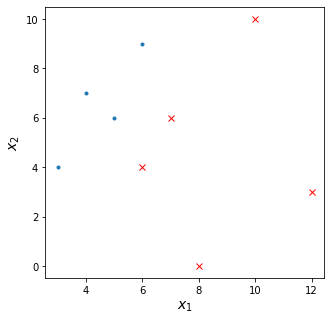

In [46]:
idx0 = np.argwhere(y == 0)
idx1 = np.argwhere(y == 1)

fig = plt.figure(figsize=(5,5))
plt.plot(x[idx0,0], x[idx0,1], '.', label='Class 0')

plt.plot(x[idx1,0], x[idx1,1], 'rx', label='Class 1')
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_2$', fontsize=14)
plt.show()

In [47]:
def dist_euclidiana(row1, row2, p): # distância euclidiana
    distance = 0.0
    for i in range(len(row1)+1):
        distance += (row1[0][i] - row2[i])**p
    return distance**(1/float(p)) #sqrt(distance)


def get_neighbors(train, test_row, num_neighbors, p, y):# neighbors
    distances = list()
    i = 0
    indices = []
    for train_row in train:
        dist = dist_euclidiana(test_row, train_row, p)
        distances.append((train_row, y[i], dist))
        indices.append(y[i])
        i = i + 1
        
    distances.sort(key=lambda tup: tup[2])
    neighbors = list()
    previsoes = list()
    for i in range(num_neighbors):
        neighbors.append(distances[i][0])
        previsoes.append(distances[i][1])
    return neighbors, previsoes
    
def previsão_classe(train, test_row, num_neighbors, p, y): 
    neighbors, previsoes = get_neighbors(train, test_row, num_neighbors, p, y)
    output_values = previsoes
    prediction = max(set(output_values), key=output_values.count)
    return prediction

In [48]:
prediction = previsão_classe(x, x_test, 3, 2, y)
print('Classificação sem Sklearn usando dados de treinamento')
print('Pertence a classe', prediction)

Classificação sem Sklearn usando dados de treinamento
Pertence a classe 1


Classificação com Sklearn usando dados de treinamento


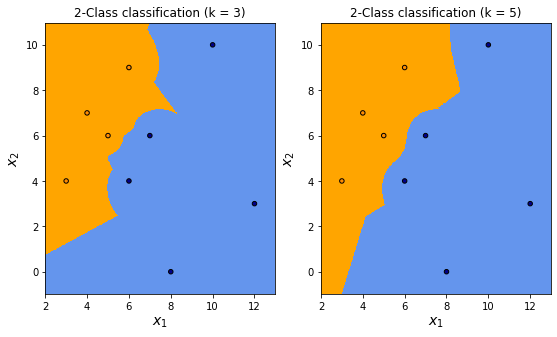

In [49]:
print('Classificação com Sklearn usando dados de treinamento')

# Step size in the mesh.
h = .02 

# Create color maps
cmap_light = ListedColormap(['orange', 'cyan', 'cornflowerblue'])
cmap_bold = ListedColormap(['darkorange', 'c', 'darkblue'])

inc = 0
plt.figure(figsize=(14, 5))
for k in [3, 5]:
    # Create an instance of Neighbours Classifier and fit the data.
    clf = KNeighborsClassifier(k, weights='distance', algorithm='auto', leaf_size=30, p=2, metric='minkowski')
    # Train the classifier.
    clf.fit(x, y)

    # Plot the decision boundary. For that, we will assign a color to each point in the mesh [x_min, x_max]x[y_min, y_max].
    x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
    y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot.
    Z = Z.reshape(xx.shape)
    ax = plt.subplot(1, 3, inc + 1)
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    # Plot also the training points.
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('$x_1$', fontsize=14)
    plt.ylabel('$x_2$', fontsize=14)
    plt.title("2-Class classification (k = %i)" % (k))
    inc = inc + 1
plt.show()

Classificação com Sklearn usando dados de mostra de validação


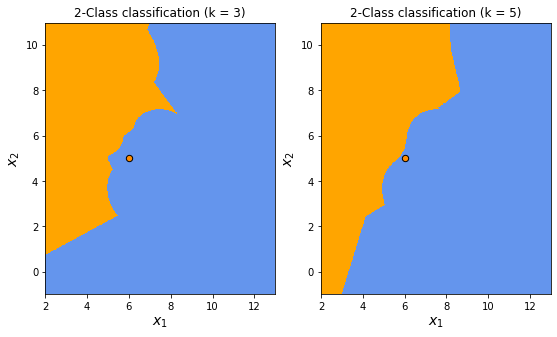

Quando k=3 a amostra de validação pertence a classe 1

Quando k=5 a amostra de validação pertence a classe 1


In [50]:
print('Classificação com Sklearn usando dados de mostra de validação')

# Step size in the mesh.
h = .02 

# Create color maps
cmap_light = ListedColormap(['orange', 'cyan', 'cornflowerblue'])
cmap_bold = ListedColormap(['darkorange', 'c', 'darkblue'])

inc = 0
plt.figure(figsize=(14, 5))
for k in [3, 5]:
    # Create an instance of Neighbours Classifier and fit the data.
    clf = KNeighborsClassifier(k, weights='distance', algorithm='auto', leaf_size=30, p=2, metric='minkowski')
    # Train the classifier.
    clf.fit(x, y)

    # Plot the decision boundary. For that, we will assign a color to each point in the mesh [x_min, x_max]x[y_min, y_max].
    x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
    y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot.
    Z = Z.reshape(xx.shape)
    ax = plt.subplot(1, 3, inc + 1)
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    y_test = clf.predict(x_test)
    # Plot the training points.
    plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test, cmap=cmap_bold, edgecolor='k', s=40)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('$x_1$', fontsize=14)
    plt.ylabel('$x_2$', fontsize=14)
    plt.title("2-Class classification (k = %i)" % (k))
    inc = inc + 1
plt.show()
print('Quando k=3 a amostra de validação pertence a classe 1\n')
print('Quando k=5 a amostra de validação pertence a classe 1')

In [51]:
print('Classificação sem Sklearn usando dados de mostra de validação\n')
for k in [3, 5]:
    print('para k = ',k)
    
    # Create an instance of Neighbours Classifier and fit the data.
    clf = KNeighborsClassifier(k, weights='distance')
    # Train the classifier.
    clf.fit(x, y)
    y_test = clf.predict(x_test)
    print('pertence a classe ', y_test)
    print(clf.kneighbors(x_test), '\n')

Classificação sem Sklearn usando dados de mostra de validação

para k =  3
pertence a classe  [1]
(array([[1.        , 1.41421356, 1.41421356]]), array([[4, 5, 1]], dtype=int64)) 

para k =  5
pertence a classe  [1]
(array([[1.        , 1.41421356, 1.41421356, 2.82842712, 3.16227766]]), array([[4, 1, 5, 0, 2]], dtype=int64)) 

